In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import savgol_filter
pd.set_option('display.max_columns', None)

# Direct Spike

In [8]:
dataDir = ' ' # 'Data_folder'
slice = pd.read_csv(dataDir+' ', delimiter=',', header=[0,1]) # 'Slice_data.csv'
slice.head(0)

Empty DataFrame
Columns: [(Control, 1p), (Control, 1p.1), (Control, 1p.2), (Control, 1p.3), (Control, 1p.4), (Control, 1p.5), (Control, 1p.6), (Control, 1p.7), (Control, 4p 50 Hz), (Control, 4p 100 Hz), (Control, 1p x), (Control, 4p 100 Hz.1), (Control, 4p 50 Hz.1), (Control, 1p x.1), (Control, 4p 50 Hz.2), (Control, 4p 100 Hz.2), (Control, 1p x.2), (DHBE, 1p), (DHBE, 1p.1), (DHBE, 1p.2), (DHBE, 1p.3), (DHBE, 1p.4), (DHBE, 1p.5), (DHBE, 1p.6), (DHBE, 1p.7), (DHBE, 4p 50 Hz), (DHBE, 4p 100 Hz), (DHBE, 4p 100 Hz mistake), (DHBE, 1p x), (DHBE, 4p 100 Hz.1), (DHBE, 4p 50 Hz.1), (DHBE, 1p x.1), (DHBE, 4p 50 Hz.2), (DHBE, 4p 100 Hz.2), (DHBE, 1p.8)]
Index: []

In [9]:
dhbe_mean = slice['DHBE'][['1p x', '1p x.1', '1p.8']].mean(axis=1)  # Lu
# dhbe_mean = slice['DHBE'][['1p.8', '1p.9', '1p.10']].mean(axis=1)  # Mark

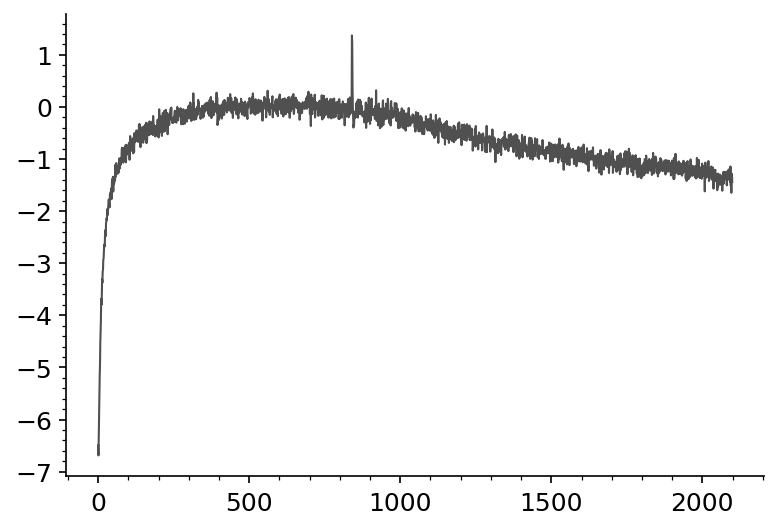

In [10]:
%matplotlib inline
plt.plot(dhbe_mean)

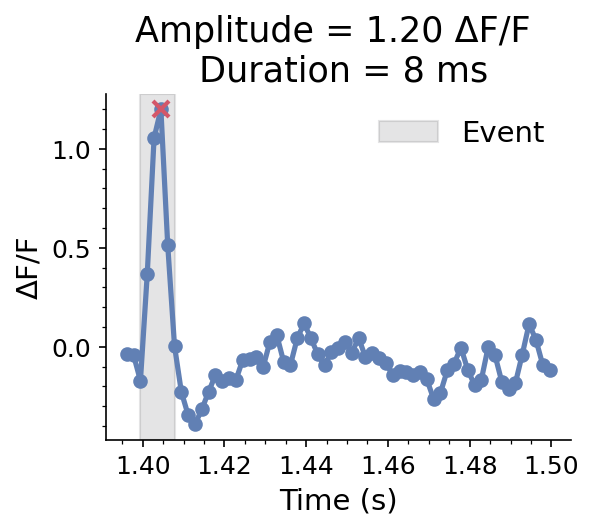

In [11]:
%matplotlib inline
fps = 599.52
start = int(fps* 1.395)
end = int(fps* 1.5)
time = np.arange(0.001668, 3.502802, 0.001668)


smoothed_trace = savgol_filter(dhbe_mean, window_length=int(5), polyorder=2)
base = smoothed_trace[int(fps*1.295):int(fps*1.395)]
base_mean = np.mean(base)
base_std = np.std(base)

seg_start = int(fps*1.4)
base_rise = np.where(smoothed_trace[seg_start:] > base_mean+base_std)[0][0]
event_start = time[(seg_start-1 + base_rise)]
direct_event_amp = np.max(smoothed_trace[int(fps*event_start):end])
peak_idx = int(fps*event_start) + np.argmax(smoothed_trace[int(fps*event_start):end])
base_return = np.where(smoothed_trace[peak_idx:] <= base_mean+base_std)[0][0]
event_end = time[peak_idx + base_return]
direct_event_duration_ms = (event_end - event_start) * 1000


fig, ax = plt.subplots(1, figsize=(4,3))

ax.plot(time[start:end], smoothed_trace[start:end], '-o', color='C3', linewidth=2.5)
ax.axvspan(event_start, event_end, color='C0', alpha=0.15, label='Event')
ax.set_title(f'Amplitude = {direct_event_amp:.2f} ΔF/F \n Duration = {direct_event_duration_ms:.0f} ms')
ax.set(ylabel='ΔF/F', xlabel='Time (s)')
ax.plot(time[peak_idx], direct_event_amp, marker='x', color='C1', markersize=8, mew=2)
ax.legend()

In [56]:
direct_event_metrics = pd.DataFrame({
    'Max DFF': [direct_event_amp],
    'Duration (ms)':  [direct_event_duration_ms]
},
                            index=[ ] # Input date here
)
direct_event_metrics

,Max DFF,Duration (ms)
240219,1.198829,8.34


# nAChR Evoked

In [61]:
dataDir = ' ' # 'Data_folder'
slice = pd.read_csv(dataDir+' ', delimiter=',', header=[0,1]) # 'Slice_data.csv'
slice.head(0)

Empty DataFrame
Columns: [(Control, 1p), (Control, 1p.1), (Control, 1p.2), (Control, 1p.3), (Control, 1p.4), (Control, 1p.5), (Control, 1p.6), (Control, 1p.7), (Control, 4p 50 Hz), (Control, 4p 100 Hz), (Control, 1p x), (Control, 4p 100 Hz.1), (Control, 1p x.1), (Control, 4p 50 Hz.1), (Control, 4p 100 Hz.2), (Control, 4p 50 Hz.2), (Control, 1p x.2), (DHBE, 1p), (DHBE, 1p.1), (DHBE, 1p.2), (DHBE, 1p.3), (DHBE, 1p.4), (DHBE, 1p.5), (DHBE, 1p.6), (DHBE, 1p.7), (DHBE, 4p 50 Hz), (DHBE, 4p 100 Hz), (DHBE, 1p x), (DHBE, 4p 100 Hz.1), (DHBE, 1p x.1), (DHBE, 4p 50 Hz.1), (DHBE, 4p 50 Hz.2), (DHBE, 4p 100 Hz.2), (DHBE, 1p x.2)]
Index: []

In [58]:
control_mean = slice['Control'][['1p x', '1p x.1', '1p x.2']].mean(axis=1)  # Lu
dhbe_mean = slice['DHBE'][['1p x', '1p x.1', '1p x.2']].mean(axis=1)  # Lu
# control_mean = slice['Control'][['1p.8', '1p.9', '1p.10']].mean(axis=1)  # Mark
# dhbe_mean = slice['DHBE'][['1p.8', '1p.9', '1p.10']].mean(axis=1)  # Mark
nAChR = control_mean - dhbe_mean

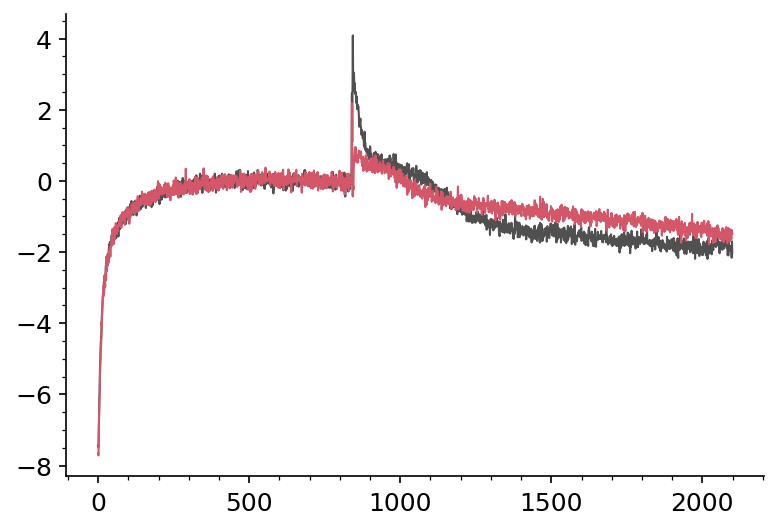

In [59]:
%matplotlib inline
plt.plot(control_mean)
plt.plot(dhbe_mean)

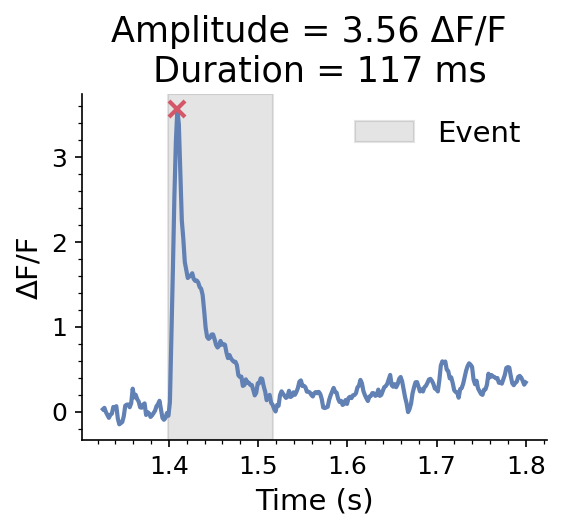

In [60]:
%matplotlib inline

fps = 599.52
start = int(fps* 1.325)
end = int(fps* 1.8)
time = np.arange(0.001668, 3.502802, 0.001668)
smoothing = 9

# number of consecutive points required to find end of event
consecutive = 3


smoothed_trace = savgol_filter(nAChR, window_length=int(smoothing), polyorder=2)
base = smoothed_trace[int(fps*1.3):int(fps*1.4)]
base_mean = np.mean(base)
base_std = np.std(base)
threshold = base_mean + base_std
seg_start = int(fps*1.4)
base_rise = np.where(smoothed_trace[seg_start:] > threshold)[0][0]
event_start = time[(seg_start + base_rise)-1]
nAChR_event_amp = np.max(smoothed_trace[int(fps*event_start):end])
peak_idx = int(fps*event_start) + np.argmax(smoothed_trace[int(fps*event_start):end])


mask = (smoothed_trace[peak_idx:] <= threshold).astype(int)   # Returns only points that are below the threshold
conv = np.convolve(mask, np.ones(consecutive, dtype=int), mode='valid') # At every time point, how many of the next samples are below threshold
base_return = int(np.flatnonzero(conv == consecutive)[0])   # Of the five conseuctive points below threshold, use the first as the 'base_return'
event_end = time[peak_idx + base_return]
nAChR_event_duration_ms = (event_end - event_start) * 1000


fig, ax = plt.subplots(1, figsize=(4,3))

ax.plot(time[start:end], smoothed_trace[start:end], '-', color='C3', linewidth=2)
ax.axvspan(event_start, event_end, color='C0', alpha=0.15, label='Event')
ax.set_title(f'Amplitude = {nAChR_event_amp:.2f} ΔF/F \n Duration = {nAChR_event_duration_ms:.0f} ms')
ax.set(ylabel='ΔF/F', xlabel='Time (s)')
ax.plot(time[peak_idx], nAChR_event_amp, marker='x', color='C1', markersize=8, mew=2)
ax.legend()

In [62]:
nAChR_event_metrics = pd.DataFrame({
    'Max DFF': [nAChR_event_amp],
    'Duration (ms)':  [nAChR_event_duration_ms]
},
                            index=[ ] # Input date here
)
nAChR_event_metrics

,Max DFF,Duration (ms)
240206,3.557728,116.76


In [114]:
event_metrics.to_csv(dataDir + ' ') # 'Output_folder_path/file_name.csv'